# Targeted subgroup analysis: Overall group

1. Cleaning/ validation steps
2. Overall response distribution
3. Counts and proportions by condition
    - Goal Type
    - Agency
    - Goal Type x Agency

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Read data

In [2]:
merged_data = pd.read_csv("../../data/processed/merged_clean.csv")

## 1. Cleaning/ validation steps

Subset data for subgroup: 

- Proficiency: Per_Level_Label = ["B2.1", "B2.2", "C1"]
- Exposure: Prof_Use_Label = "Yes"

In [3]:
subgroup = merged_data[
    (merged_data["Per_Level_Label"].isin(["B2.1", "B2.2", "C1"])
    ) & (merged_data["Prof_Use_Label"] == "Yes")      
]

Subgroup validation

In [4]:
subgroup.shape

(198, 31)

In [5]:
subgroup.columns

Index(['Participant_ID', 'Focus', 'Agent', 'Goal_Type', 'Item', 'Item_string',
       'Item_len', 'Response_tag', 'Response', 'Response_Full', 'EXP', 'n',
       'Age', 'Gender', 'Kno_Level', 'Per_Level', 'Bilingual', 'Bi_Parents',
       'Multi_Kno', 'Multi_Spk', 'Immersion', 'Prof_Need', 'Prof_Use',
       'Motivation', 'Distractor', 'GN_Score', 'Difficulty', 'Kno_Level_Label',
       'Per_Level_Label', 'Prof_Need_Label', 'Prof_Use_Label'],
      dtype='str')

Check duplicated values

In [6]:
subgroup.duplicated().sum()

np.int64(0)

In [7]:
subgroup.head()

,Participant_ID,Focus,Agent,Goal_Type,Item,Item_string,Item_len,Response_tag,Response,Response_Full,...,Prof_Need,Prof_Use,Motivation,Distractor,GN_Score,Difficulty,Kno_Level_Label,Per_Level_Label,Prof_Need_Label,Prof_Use_Label
0,EXP1_01,I,1,no_goal,Item1,"""If I had heard the rainstorm, I would have fe...",11,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
1,EXP1_01,I,1,no_goal,Item2,"""If I had climbed the mountain cliff, I would ...",12,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
2,EXP1_01,I,1,goal_non_frequent,Item1,"""If I had created an online platform, I would ...",14,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
3,EXP1_01,I,1,goal_non_frequent,Item2,"""If I had invested in technology, I would have...",13,correct_3,correct,correct,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
4,EXP1_01,I,1,goal_frequent,Item1,"""If I had saved money, I would have gone on ho...",11,correct_3,correct,correct,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes


## 2. Overall response distribution

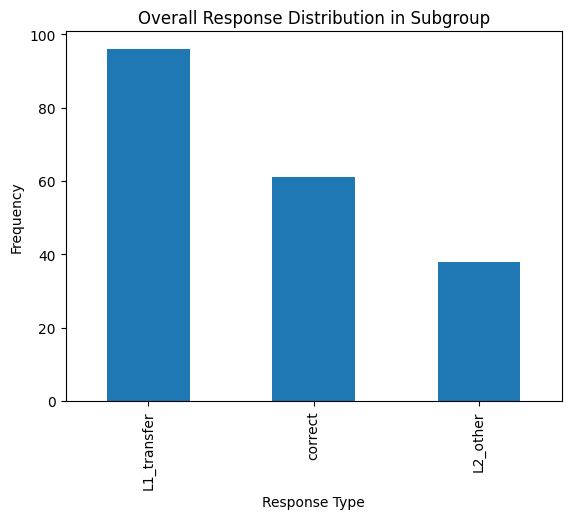

In [8]:
subgroup["Response_Full"].value_counts().plot(kind = "bar")

plt.title("Overall Response Distribution in Subgroup")
plt.xlabel("Response Type")
plt.ylabel("Frequency")

plt.show()

As expected, with perceived advanced learners who actively use L2-English professionally, L1_transfer dominates the reponse landscape. This actually shows that learners do commit to a resolution but somewhere along the process theres is resolve competition. Transfer might represent a stabilized processing solution.

## 3. Counts and proportions by condition

**Responses by Goal Type:**

- Counts
- Proportions 
- Proportions plot

In [27]:
goal_response_counts = pd.crosstab(
    subgroup["Goal_Type"],
    subgroup["Response_Full"],
    dropna = False, 
    margins= True
)

goal_response_counts

Response_Full,L1_transfer,L2_other,correct,NaN,All
Goal_Type,,,,,
goal_frequent,25,16,24,1,66
goal_non_frequent,37,10,19,0,66
no_goal,34,12,18,2,66
All,96,38,61,3,198


In [28]:
goal_response_props = pd.crosstab(
    subgroup["Goal_Type"],
    subgroup["Response_Full"],
    dropna= False,
    normalize="index"
)

goal_response_props

Response_Full,L1_transfer,L2_other,correct,NaN
Goal_Type,,,,
goal_frequent,0.378788,0.242424,0.363636,0.015152
goal_non_frequent,0.560606,0.151515,0.287879,0.000000
no_goal,0.515152,0.181818,0.272727,0.030303


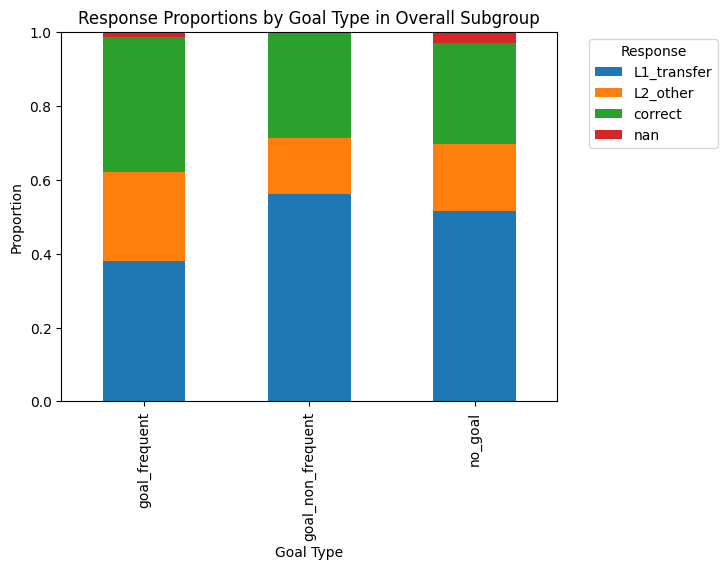

In [29]:
goal_response_props.plot(kind="bar", stacked=True)

plt.title("Response Proportions by Goal Type in Overall Subgroup")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

- goal_frequent, compared to non_frequent, shows the highest proportion of correct resolution and could reduce transfer pressure. This could lead to goal-congruent conceptual support could help correct target resolution; however, but we already know that explicit agency could be playing a role. 

- goal_non_frequent keeps showing the highest proportion of transfer resolution. Compared to goal_frequent, not only do correct responses decrease but also L2 alternatives. 

- no_goal distribution looks more similar to goal_non_frequent's; but there is more room for L2 alternatives again and slightly fewer tranfer responses. 

- given previous hints from analysis, the null distribution is better perceived when there is lack of explicit agency, so we shall see that next. 

**Responses by Agent:**

- Counts
- Proportions 
- Proportions plot

In [30]:
agent_response_counts = pd.crosstab(
    subgroup["Agent"],
    subgroup["Response_Full"],
    dropna= False,
    margins= True
)

agent_response_counts

Response_Full,L1_transfer,L2_other,correct,NaN,All
Agent,,,,,
0,57,31,35,3,126
1,39,7,26,0,72
All,96,38,61,3,198


In [31]:
agent_response_props = pd.crosstab(
    subgroup["Agent"],
    subgroup["Response_Full"],
    dropna= False,
    normalize="index"
)

agent_response_props

Response_Full,L1_transfer,L2_other,correct,NaN
Agent,,,,
0,0.452381,0.246032,0.277778,0.02381
1,0.541667,0.097222,0.361111,0.00000


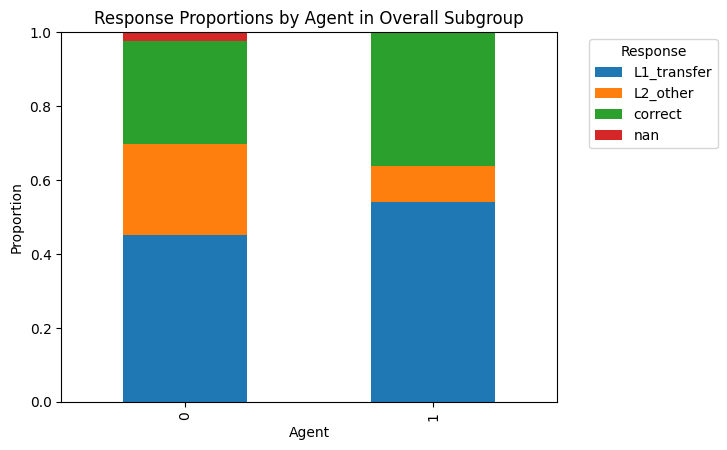

In [32]:
agent_response_props.plot(kind= "bar", stacked= True)

plt.title("Response Proportions by Agent in Overall Subgroup")
plt.xlabel("Agent")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

What stands out first is the massive reduction of L2 alternative responses when there is an explicit agent together with the increase in correct and transfer responses. We could we looking into how explicit agency could be forcing a stronger structural commitment intensifing processing while reducing ambiguity. 

This takes us back to conceptualization and encoding of responsability/ accountability and even liability in emotionally loaded scenarios -which could be further explored once the subgroup is sliced into actors and readers.

As expected, the null response distribution is entirely allocated in  the lack of explicit agent condition.

**Responses by Goal Type and Agent:**

- Counts
- Proportions 
- Proportions plot

In [33]:
goal_agent_response_props = pd.crosstab(
    [subgroup["Goal_Type"], subgroup["Agent"]],
    subgroup["Response_Full"],
    dropna= False,
    normalize="index"
)

goal_agent_response_props

Response_Full            L1_transfer  L2_other   correct       NaN
Goal_Type         Agent                                           
goal_frequent     0         0.309524  0.333333  0.333333  0.023810
                  1         0.500000  0.083333  0.416667  0.000000
goal_non_frequent 0         0.500000  0.214286  0.285714  0.000000
                  1         0.666667  0.041667  0.291667  0.000000
no_goal           0         0.547619  0.190476  0.214286  0.047619
                  1         0.458333  0.166667  0.375000  0.000000

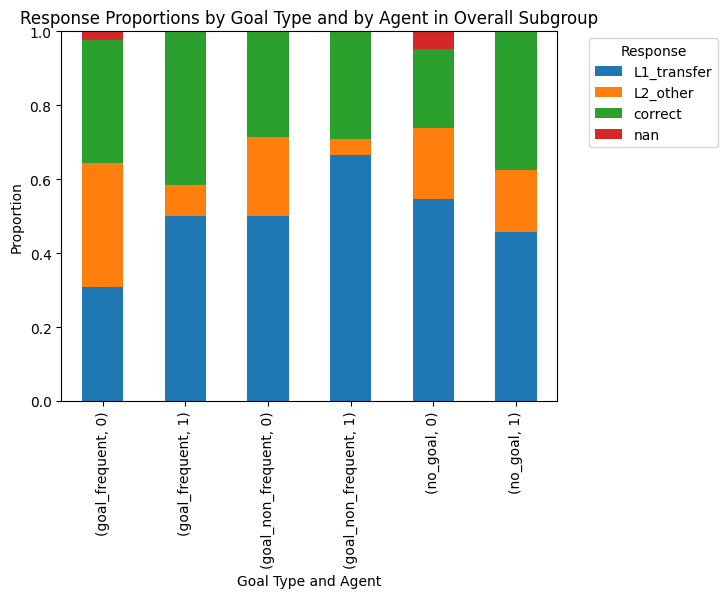

In [34]:
goal_agent_response_props.plot(kind="bar", stacked= True)

plt.title("Response Proportions by Goal Type and by Agent in Overall Subgroup")
plt.xlabel("Goal Type and Agent")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

This interactions patterns are coherent considering previous exploration. 

- goal_frequent and explicit agent shows the highest proportion of correct resolution, transfer responses increase and L2 alternatives are highly reduced. This confirms that the system commits in 2 competing directions: sucessful target restructuring or transfer.

- goal_non_frequent shows a similar pattern alhought the proportion of increased correct responses is minimal, which implies that explicit agency is not improving correctness. What stands out is how tansfer responses increase from 0.50 to 0.66 with explicit agency. This condition is the one that could take us to explore explicit causation and emotional load; however, it already raises a concern:

    - goal_frequent is a neutral goal and goal_non_frequent is not a neutral goal but and *emotionally loaded* one by experimental design. This cannot be undone and, therefore, whatever found future differences -should there be any- won't be clearly pointing to goal-type restructuring or emotional-causal restructuring. 

- no_goal and no agent shows the lowest correct performance and the highest proportion of missing responses. Now, when the explicit agent comes in, correct performance increases and transfer proportion decresases. They appear to lose conceptual anchoring. This is what pedagogically would be expected from proficient learners but does not happen to the other goal types, so:

    - no_goal could be showing an entirely different processing behaviour; in which case, compared to the other goals, agency should be regarded as a modulator or a conceptual organizer and not only a grammatical facilitator. 
